# Exercises

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
from scipy.optimize import minimize
import sys


sns.set_theme(context='notebook',style='white',font_scale=1.5,
              rc = {'axes.spines.top':False,'axes.spines.right':False})


print(sys.path)
sys.path.append('C:/Users/Beheerder/OneDrive/Documents/Radboud Universiteit/Master/Neuro Analysis/neural-data-master/Neuro_Analysis_def/2-single-cell-analysis-master/02-GLMs/code')


['c:\\Users\\Beheerder\\miniforge3\\python310.zip', 'c:\\Users\\Beheerder\\miniforge3\\DLLs', 'c:\\Users\\Beheerder\\miniforge3\\lib', 'c:\\Users\\Beheerder\\miniforge3', '', 'C:\\Users\\Beheerder\\AppData\\Roaming\\Python\\Python310\\site-packages', 'C:\\Users\\Beheerder\\AppData\\Roaming\\Python\\Python310\\site-packages\\win32', 'C:\\Users\\Beheerder\\AppData\\Roaming\\Python\\Python310\\site-packages\\win32\\lib', 'C:\\Users\\Beheerder\\AppData\\Roaming\\Python\\Python310\\site-packages\\Pythonwin', 'c:\\Users\\Beheerder\\miniforge3\\lib\\site-packages']


In [6]:
#import supporting functions
from utilities import create_receptive_field

## Exercise 1
---
Determine the effect of stimulus sequence duration on RF estimates. To do this, repeat the above steps for different durations (5 s, 10 s, 20 s, 40 s, 80 s, 160 s, 320 s, 640 s). Compute the Pearson correlation between true and estimated RFs for each duration to quantify the accuracy of the estimator. The Pearson correlation $\mathrm{cc}$ is defined as
$$
\mathrm{cc} = \frac{\mathbf{k}_\mathrm{true}^T \hat{\mathbf{k}}}{\lVert \mathbf{k}_\mathrm{true} \rVert \lVert \hat{\mathbf{k}} \rVert}
$$
where $\lVert \cdot \rVert$ is the L2-norm (vector length).
As the response generation process is stochastic, compute the average correlation across 10 realizations for the same duration and plot the average correlation as a function of duration. How is the recording duration related to the ability to recover the true RF?

        To do this, we have to do the same but create a loop for the code, see below. Just as in the lecture notes, we generated a stimulus, simulated the spiking responses, estimated the RF and computed the Pearson's correlation between the real and estimated RF. As we have know, the Pearson's correlation between the estimated RF and the true RF shows how well the model recovers the true signal. What we see in the plot is that the average Pearson's correlation increases when we increase the stimulus duration. This makes sense and also correspond to what was said in the lecture, as with longer recordings, the model has access to more data, which improves the signal-to-noise ratio when estimating the RF. This allows the model to estimate a better fit for the RF, which increases the reliability of the estimate, also increasing the Pearson's correlation.



In [ ]:
#use generate linear data function but make sure it is adapted so that it doesn't return any negative outputs

def generate_data_linear_1(S, K, dt=0.1, offset=2.0, noise_variance=4, f_nonlin=lambda x: np.maximum(0, x)):
    n_bins = S.shape[0]
    X_flat = S.reshape(n_bins, -1)
    k_flat = K.flatten()

    #linear projection + offset
    lin_output = X_flat @ k_flat + offset

    #apply nonlinearity
    rate = f_nonlin(lin_output)

    #add noise
    rate += np.sqrt(noise_variance) * np.random.randn(*rate.shape)

    #no negative or invalid values to ensure valid poisson
    rate = np.clip(rate, 0, None)

    #Poisson spike generation
    spikes = np.random.poisson(rate * dt)

    return spikes, X_flat, K, rate


In [ ]:
durations = [5, 10, 20, 40, 80, 160, 320, 640]
dt = .1
vf_size = (15,15)
repeats = 10

# Create true RF
K_true = create_receptive_field()

avg_correlations = []

In [ ]:
for duration in durations:
    n_bins = round(duration / dt)
    correlations = []

    for _ in range(repeats):
        #create Gaussian stimulus
        S = np.random.randn(n_bins, *vf_size)

        #simulate spikes using the linear model
        spikes, X_flat, _, _ = generate_data_linear_1(S, K_true, dt)

        #estimate the RF
        K_est_flat = np.linalg.pinv(X_flat) @ spikes
        K_est = K_est_flat.reshape(vf_size)

        #Pearsons correlation between true and estimated RF
        cc = np.corrcoef(K_true.flatten(), K_est.flatten())[0, 1]
        correlations.append(cc)

    #average over all repeats
    avg_correlations.append(np.mean(correlations))

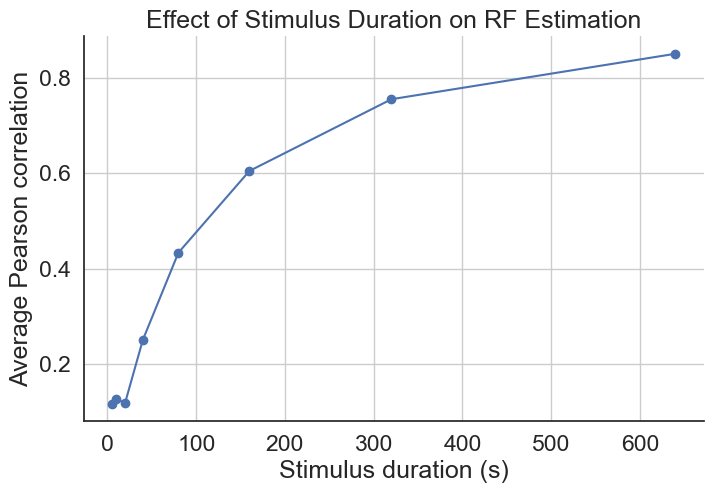

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(durations, avg_correlations, marker='o')
plt.xlabel('Stimulus duration (s)')
plt.ylabel('Average Pearson correlation')
plt.title('Effect of Stimulus Duration on RF Estimation')
plt.grid(True)
plt.show()

## Exercise 2
---

Determine the effect of response noise ($\sigma^2$) on RF estimates. Try different value for the noise variance in the simulations, e.g., 0, 2, 4, 6, 8, and 10 for a duration of 100 s. As in the previous excercise, repeatedly estimate RF parameters for each condition (10 times) but this time also plot the standard deviation of the correlations across the different runs for each condition.

        As in exercise 1, a higher Pearson's correlation means a higher signal-to-noise ratio, meaning it is a better estimate of the true signal. When we increase the noise variance, (so a larger $\sigma^2$), the estimates become less reliable, reducing the signal-to-noise ratio. As a result, not only the average Pearson's correlation decreases, but also the variance (or standard deviation) of the correlations increases, as the noise increases across the runs. These larger standard deviations also show that the fit of our model is more unreliable.


In [ ]:
#new parameters
duration = 100  
noise_levels = [0, 2, 4, 6, 8, 10]

#create a true RF
K_true = create_receptive_field()
S = std_dev * np.random.randn(n_bins,vf_size[0],vf_size[1])

#linear model 
def generate_data_linear_2(S, K, dt=0.1, offset=2.0, noise_variance=4, f_nonlin=lambda x: np.maximum(0, x)):
    n_bins = S.shape[0]
    X_flat = S.reshape(n_bins, -1)
    k_flat = K.flatten()

    lin_output = X_flat @ k_flat + offset
    rate = f_nonlin(lin_output)
    rate += np.sqrt(noise_variance) * np.random.randn(*rate.shape)
    rate = np.clip(rate, 0, None)
    spikes = np.random.poisson(rate * dt)

    return spikes, X_flat, K, rate

#to collect the results:
avg_correlations = []
std_correlations = []

n_bins = round(duration / dt)

for noise_var in noise_levels:
    correlations = []

    for _ in range(repeats):
        #generate stimulus
        S = np.random.randn(n_bins, *vf_size)

        #simulate spike responses with current noise variance
        spikes, X_flat, _, _ = generate_data_linear_2(S, K_true, dt, noise_variance=noise_var)

        #estimate RF
        K_est_flat = np.linalg.pinv(X_flat) @ spikes
        K_est = K_est_flat.reshape(vf_size)

        #Pearsons correlation
        cc = np.corrcoef(K_true.flatten(), K_est.flatten())[0, 1]
        correlations.append(cc)

    avg_correlations.append(np.mean(correlations))
    std_correlations.append(np.std(correlations))

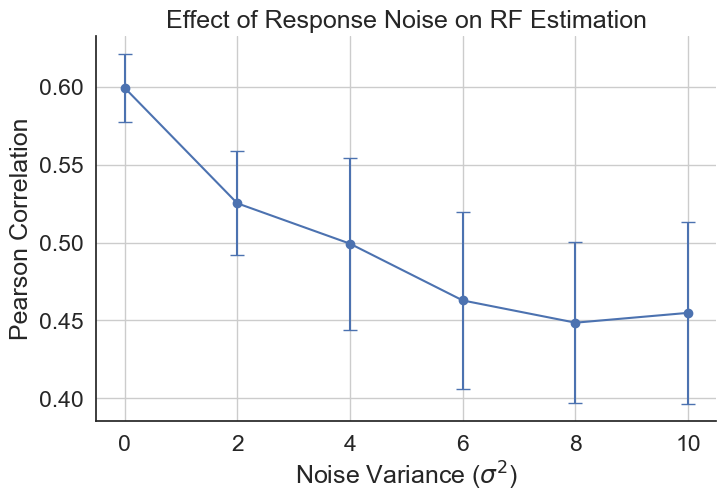

In [16]:
# Plotting
plt.figure(figsize=(8, 5))
plt.errorbar(noise_levels, avg_correlations, yerr=std_correlations, fmt='-o', capsize=5)
plt.xlabel('Noise Variance ($\sigma^2$)')
plt.ylabel('Pearson Correlation')
plt.title('Effect of Response Noise on RF Estimation')
plt.grid(True)
plt.show()


## Exercise 3
---
Look at the analytical derivation of the log-likelihood for the poisson GLM.
Which of the terms are required for maximizing the likelihood with respect to $\mathbf{k}$ and which terms can be ignored? **Note:** due to the independence of spikes in the different bins, the likelihood can be written as $P(R | S, \mathbf{k}) = \prod_t^T P(r_t | \mathbf{s}_t, \mathbf{k})$. The log turns the product into a sum which makes life much easier.  

        When maximizing the log-likelihood for the poisson GLM, we only care about the terms that depend on K as we are interested in finding the K that makes the log-likelihood as large as possible. terms that do not depend on k do not influence the maximum because adding or subtractting a constant just shifts the entire log-likelihood up or down without changing the shape of the curve. Therefore, constants do not contribute to the optimization of the function and can be dropped to simplify the calculations that we want to do.

$r_t \log \Delta$ and $\log r_t!$  are constant terms that do not depend on k, leaving:

$$
\mathcal{L}(\mathbf{k}) = \sum_t \left[ r_t \mathbf{k}^\top \mathbf{s}_t - \Delta \exp(\mathbf{k}^\top \mathbf{s}_t) \right]
$$

        The gradient of the log-likelihood with respect to k is:

$$
\frac{\partial \log P}{\partial \mathbf{k}} = \sum_t r_t \mathbf{s}_t - \Delta \sum_t \lambda_t \mathbf{s}_t
$$

        where 
$$
\lambda_t = \exp\left(\mathbf{k}^\top \mathbf{s}_t \right)
$$


## Exercise 4
---
Explore the effect of the data duration and the firing rate on the goodness of fit of the Poisson GLM.

A - Generate data with durations of 10,20,50,100 and 200 seconds. Fit the model on each dataset and plot the fitted parameters.
Use the pearson correlation as a proxy of the goodness of fit, and plot it as a function of the duration of the data.

B - Fix the duration to 100s, and change the average firing rate of the simulation. How does the fit perform for different firing rates? 

## A. Effect of duration

        As the duration of the dataset increases, the fit should improve because more data provides better statistical power for estimating the model parameters (as we saw before). As we see in our plot, it shows a general trend of an increase in Pearsons correlation. However, something happens at 20 seconds, because there is a very large dip. This could have different reasons, such as noise, random variability or outliers in the estimated parameters specifically at 20 seconds which decreases the average correlation.10 seconds might just also be too short. As you get fewer spikes, it makes the RF estimation highly variable, so on specific runs it might be that it "accidentally" aligns quite well with the true RF leading to a higher correlation than at 20 seconds. From 50 seconds onward, the RF estimation might become more reliable, which we also see in the steady increase.

In [ ]:
#parameters
durations = [10, 20, 50, 100, 200]
dt = 0.1
std_dev = 1
vf_size = (15, 15)
repeats = 50 #increase number of repeats to get more reliable results
noise_variance = 1
offset = 2.0
spike_rate = 5 

In [49]:
def generate_data_poisson(S, K_true, offset, dt, target_rate):
    n_bins = S.shape[0]

    #flatten and prepare stimulus
    S_flat = S.reshape(n_bins, -1)
    S_flat = np.hstack((S_flat, np.ones((n_bins, 1))))  # add bias term

    #flatten and add offset to RF
    K_flat = np.hstack((K_true.ravel(), offset))

    #linear response
    lin_output = np.dot(S_flat, K_flat)

    #nonlinear output
    lamda = np.exp(lin_output)

    #adjust for target spike rate
    expected_rate = np.sum(lamda * dt) / (n_bins * dt)
    lamda *= target_rate / expected_rate

    #generate the spikes
    spike_counts = np.random.poisson(lam=lamda * dt)

    return spike_counts, S_flat


In [50]:
avg_correlations = [] #to collect the results

for duration in durations:
    n_bins = int(duration / dt)
    correlations = []

    for _ in range(repeats):
        #Gaussian stimulus:
        S = std_dev * np.random.randn(n_bins, *vf_size)

        #generate spike counts 
        spike_counts, S_flat = generate_data_poisson(S, K_true, offset, dt, spike_rate)

        #fit the GLM
        K_est_flat = np.linalg.pinv(S_flat) @ spike_counts
        K_est = K_est_flat[:-1].reshape(vf_size)  # exclude bias

        #Pearsons correlation:
        cc = np.corrcoef(K_true.ravel(), K_est.ravel())[0, 1]
        correlations.append(cc)

    avg_corr = np.mean(correlations)
    avg_correlations.append(avg_corr)
    print(f"Duration: {duration}s | Avg. Pearson Correlation: {avg_corr:.3f}")

Duration: 10s | Avg. Pearson Correlation: 0.232
Duration: 20s | Avg. Pearson Correlation: 0.134
Duration: 50s | Avg. Pearson Correlation: 0.343
Duration: 100s | Avg. Pearson Correlation: 0.484
Duration: 200s | Avg. Pearson Correlation: 0.601


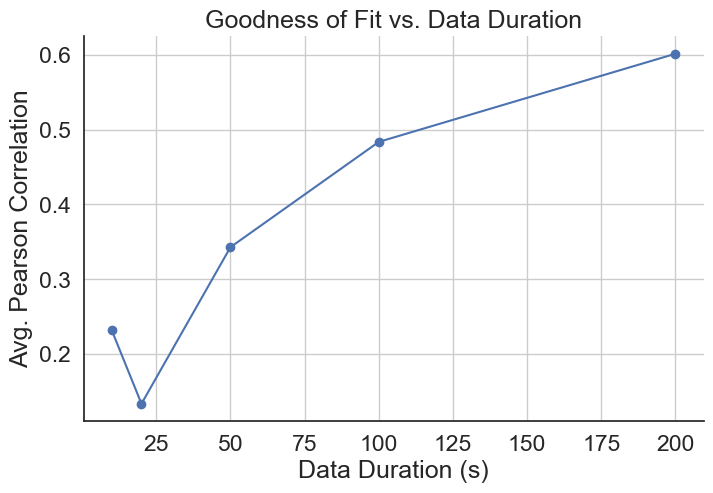

In [51]:
# Plot
plt.figure(figsize=(8, 5))
plt.plot(durations, avg_correlations, marker='o')
plt.xlabel("Data Duration (s)")
plt.ylabel("Avg. Pearson Correlation")
plt.title("Goodness of Fit vs. Data Duration")
plt.grid(True)
plt.show()

## B. Effect of firing rate

        As expected, increasing the firing rate initially improves the model's fit, with average Pearson correlation rising from 0.44 at 1 Hz to nearly 0.49 at 5 Hz. However, after 10 Hz, the model performance stabilizes and even slightly decreases, which suggetst that the Poisson GLM is not that good at reflecting high firing rate variability. This may have different reasons. Generally, at high firing rates, real neurons are more complex than this model may allow. For example, real neurons have a refractory period where they cannot fire again immediately. Or, neurons adapt at a certain point, where firing rate decreases when a stimulus has been the same for a longer period to be more sensitive to changes in that stimulus (for example when you cannot feel your clothes on your body the whole day, only when you put them on). This model might therefore be too simple to reflect neurons with a higher firing rate. 

In [56]:
#addytional parameters
duration = 100  
repeats = 50 #increase number of repeats to get more reliable estimate
n_bins = int(duration / dt)

In [57]:
#new function
def generate_data_poisson(S, K_true, offset, dt, target_rate):
    n_bins = S.shape[0]

    S_flat = S.reshape(n_bins, -1)
    S_flat = np.hstack((S_flat, np.ones((n_bins, 1))))  # add bias

    K_flat = np.hstack((K_true.ravel(), offset))
    lin_output = np.dot(S_flat, K_flat)

    lamda = np.exp(lin_output)

    #adjust to target firing rate
    expected_rate = np.sum(lamda * dt) / duration
    lamda *= target_rate / expected_rate

    spike_counts = np.random.poisson(lamda * dt)

    return spike_counts, S_flat

In [58]:
firing_rates = [1, 2, 5, 10, 20, 50]
avg_correlations = []

for fr in firing_rates:
    correlations = []

    for _ in range(repeats):
        S = std_dev * np.random.randn(n_bins, *vf_size)

        #simulate data
        spike_counts, S_flat = generate_data_poisson(S, K_true, offset, dt, fr)

        #fit the GLM again
        K_est_flat = np.linalg.pinv(S_flat) @ spike_counts
        K_est = K_est_flat[:-1].reshape(vf_size)  # drop bias term

        # Pearsons correlation
        cc = np.corrcoef(K_true.ravel(), K_est.ravel())[0, 1]
        correlations.append(cc)

    avg_corr = np.mean(correlations)
    avg_correlations.append(avg_corr)
    print(f"Firing rate: {fr} Hz | Avg. Pearson Correlation: {avg_corr:.3f}")


Firing rate: 1 Hz | Avg. Pearson Correlation: 0.441
Firing rate: 2 Hz | Avg. Pearson Correlation: 0.455
Firing rate: 5 Hz | Avg. Pearson Correlation: 0.489
Firing rate: 10 Hz | Avg. Pearson Correlation: 0.482
Firing rate: 20 Hz | Avg. Pearson Correlation: 0.451
Firing rate: 50 Hz | Avg. Pearson Correlation: 0.471


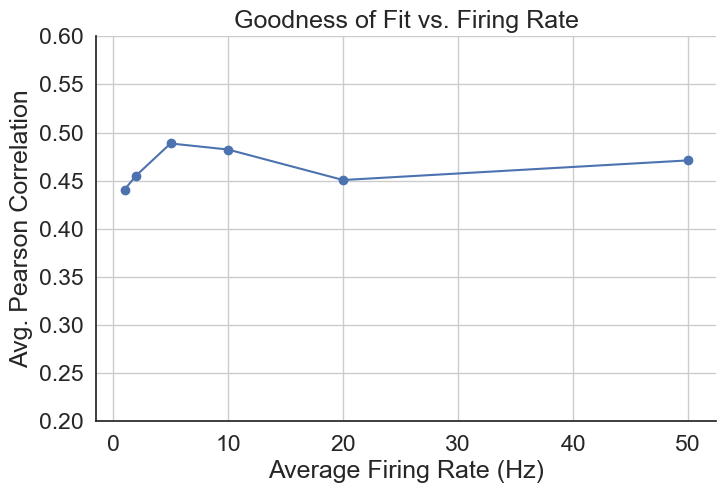

In [60]:
plt.figure(figsize=(8, 5))
plt.plot(firing_rates, avg_correlations, marker='o')
plt.xlabel("Average Firing Rate (Hz)")
plt.ylabel("Avg. Pearson Correlation")
plt.ylim(0.2,0.6)
plt.title("Goodness of Fit vs. Firing Rate")
plt.grid(True)
plt.show()